In [1]:
import os
import sys
import ast
base_directory = os.path.dirname(os.path.abspath(""))
sys.path.append(base_directory)

from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def plot_histogram(df, xcol, xlabel=None, ylabel=None, title=None, logx=False, logy=False, xmin=0, bins=20, output_path=None):
    num_na = df[xcol].isna().sum()
    print(f"Column '{xcol}' has {num_na} / {len(df)} null entries.")
    
    data = df[xcol].dropna()

    plt.figure(figsize=(10, 6))
    if logx:
        data = data[data > 0]  # remove non-positive values
        
        log_min = np.log10(data.min())
        log_max = np.log10(data.max())
        if xmin == 0:
            xmin = min(data.min(), 0.1)  # set a small positive value if min is zero
        bins = np.logspace(log_min, log_max, bins)
        
        plt.hist(data, bins=bins, edgecolor='black')
        plt.xscale('log')
    else:
        plt.hist(data, bins=bins, edgecolor='black')
    
    if xlabel is None:
        xlabel = xcol.replace("_", " ").title()
    plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)
    if logy:
        plt.yscale('log')
    if logx:
        plt.xscale('log')
    if xmin is not None:
        plt.xlim(xmin=xmin)
    if title:
        plt.title(title)
    plt.grid(axis='y', alpha=0.75)
    if output_path:
        plt.savefig(output_path)
    # plt.close()

def count_values_in_comma_joined_column(df, column_name):
    value_counts = Counter()
    for entry in df[column_name].dropna():
        for value in entry.split(","):
            value_counts[value.strip()] += 1
    labels = list(value_counts.keys())
    counts = list(value_counts.values())
    return labels, counts

def plot_bar_chart(categories, counts, xlabel, ylabel=None, title=None, output_path=None):
    plt.figure(figsize=(10, 6))
    plt.bar(categories, counts, edgecolor='black')
    plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)
    if title:
        plt.title(title)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.75)
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path)
    # plt.close()

In [3]:
df_path = os.path.join(base_directory, "data", "radiology_db.csv")

if not os.path.exists(df_path):
    raise FileNotFoundError(f"Data file not found at {df_path}. Please ensure the file exists.")

df = pd.read_csv(df_path)

df_total, df_unverified = None, None
if "verified" in df.columns and len(df["verified"].unique()) > 1:
    df_total = df.copy()
    df = df[df["verified"] == True]
    df_unverified = df_total[df_total["verified"] == False]

In [4]:
df.head()

,verified,name,num_images,num_patients,modalities,body_regions,additional_data,paper_title,paper_link,paper_year,paper_authors,paper_journal,pmid,paper_citation_count,mesh_terms,pubmed_matches,mesh_terms_in_pubmed_matches
1,1.0,The Cancer Imaging Archive (TCIA),3300000.0,NaN,"CT,MRI","chest,abdomen,pelvis,limbs",reports,The Cancer Imaging Archive (TCIA): maintaining...,https://doi.org/10.1007/s10278-013-9622-7,2013,"Clark K,Vendt B,Smith K,Freymann J,Kirby J,Kop...",Journal of digital imaging,23884657,2224,"Diagnostic Imaging,Female,Humans,Information S...","[['""information repository""[ti]'], ['""Radiolog...","""Radiology Information Systems""[MeSH]"
3,1.0,LIDC/IDRI Database,7371.0,1018.0,CT,chest,segmentation,The Lung Image Database Consortium (LIDC) and ...,https://doi.org/10.1118/1.3528204,2011,"Armato SG,McLennan G,Bidaut L,McNitt-Gray MF,M...",Medical physics,21452728,938,"Databases, Factual,Diagnosis, Computer-Assiste...","[['database[ti]'], ['""Medical Imaging""[tiab]',...",NaN
5,1.0,MIMIC-CXR,377110.0,65379.0,X-ray,chest,reports,"MIMIC-CXR, a de-identified publicly available ...",https://doi.org/10.1038/s41597-019-0322-0,2019,"Johnson AEW,Pollard TJ,Berkowitz SJ,Greenbaum ...",Scientific data,31831740,579,"Algorithms,Data Mining,Databases, Factual,Huma...","[['database[ti]'], ['radiology[tiab]']]",NaN
6,1.0,UK Biobank,NaN,100000.0,"MRI,X-ray,US","brain,abdomen,chest",genomics,"The UK Biobank imaging enhancement of 100,000 ...",https://doi.org/10.1038/s41467-020-15948-9,2020,"Littlejohns TJ,Holliday J,Gibson LM,Garratt S,...",Nature communications,32457287,535,"Adult,Aged,Biological Specimen Banks,Female,Hu...","[['""data collection""[ti]'], ['""X-ray""[tiab]', ...",NaN
7,1.0,MIMIC-II,NaN,25328.0,NaN,NaN,"reports,captions,segmentation",Multiparameter Intelligent Monitoring in Inten...,https://doi.org/10.1097/CCM.0b013e31820a92c6,2011,"Saeed M,Villarroel M,Reisner AT,Clifford G,Leh...",Critical care medicine,21283005,505,"Adult,Artificial Intelligence,Critical Care,Da...","[['database[ti]'], ['radiology[tiab]']]",NaN


In [5]:
list(df.columns)

['verified',
 'name',
 'num_images',
 'num_patients',
 'modalities',
 'body_regions',
 'additional_data',
 'paper_title',
 'paper_link',
 'paper_year',
 'paper_authors',
 'paper_journal',
 'pmid',
 'paper_citation_count',
 'mesh_terms',
 'pubmed_matches',
 'mesh_terms_in_pubmed_matches']

In [6]:
print(df.iloc[0])

verified                                                                      1.0
name                                            The Cancer Imaging Archive (TCIA)
num_images                                                              3300000.0
num_patients                                                                  NaN
modalities                                                                 CT,MRI
body_regions                                           chest,abdomen,pelvis,limbs
additional_data                                                           reports
paper_title                     The Cancer Imaging Archive (TCIA): maintaining...
paper_link                              https://doi.org/10.1007/s10278-013-9622-7
paper_year                                                                   2013
paper_authors                   Clark K,Vendt B,Smith K,Freymann J,Kirby J,Kop...
paper_journal                                          Journal of digital imaging
pmid            

# Plot number of images, patients

Column 'num_images' has 9 / 20 null entries.
Column 'num_patients' has 6 / 20 null entries.


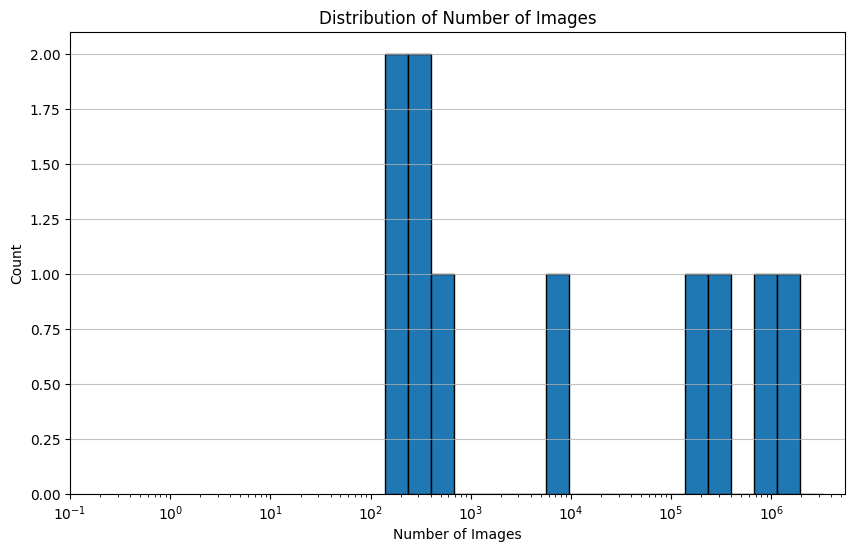

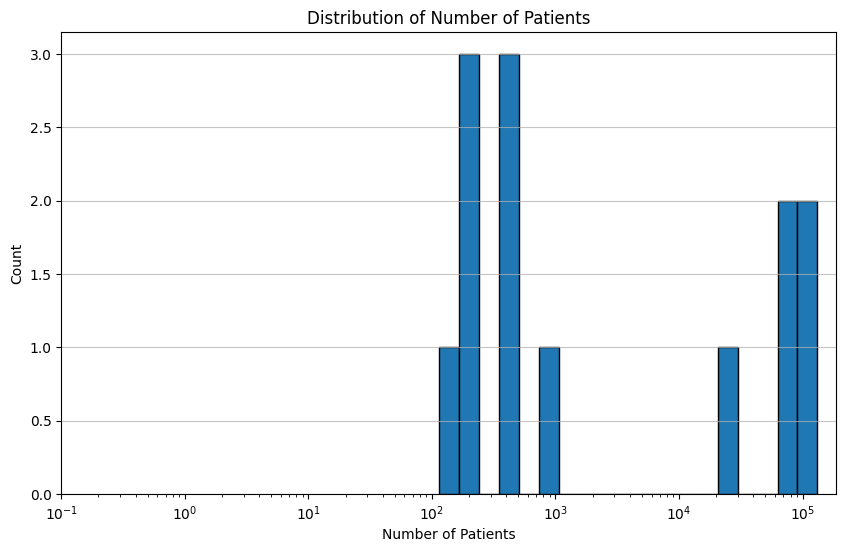

In [7]:
plot_histogram(df, "num_images", title="Distribution of Number of Images", xlabel="Number of Images", ylabel="Count", logx=True)
plot_histogram(df, "num_patients", title="Distribution of Number of Patients", xlabel="Number of Patients", ylabel="Count", logx=True)

Column 'images_per_patient' has 12 / 20 null entries.


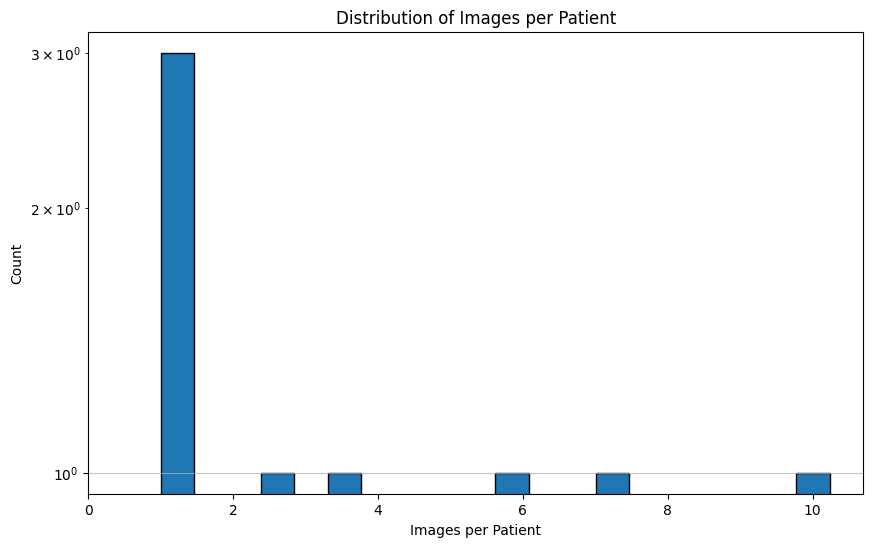

In [8]:
df["images_per_patient"] = df["num_images"] / df["num_patients"]
plot_histogram(df, "images_per_patient", title="Distribution of Images per Patient", xlabel="Images per Patient", ylabel="Count", logy=True)

# Modalities

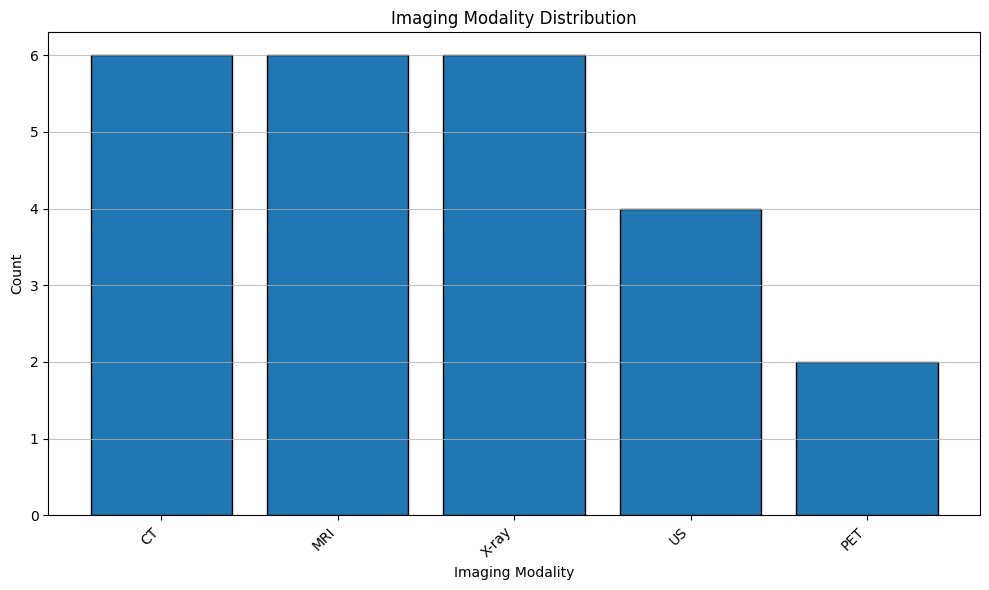

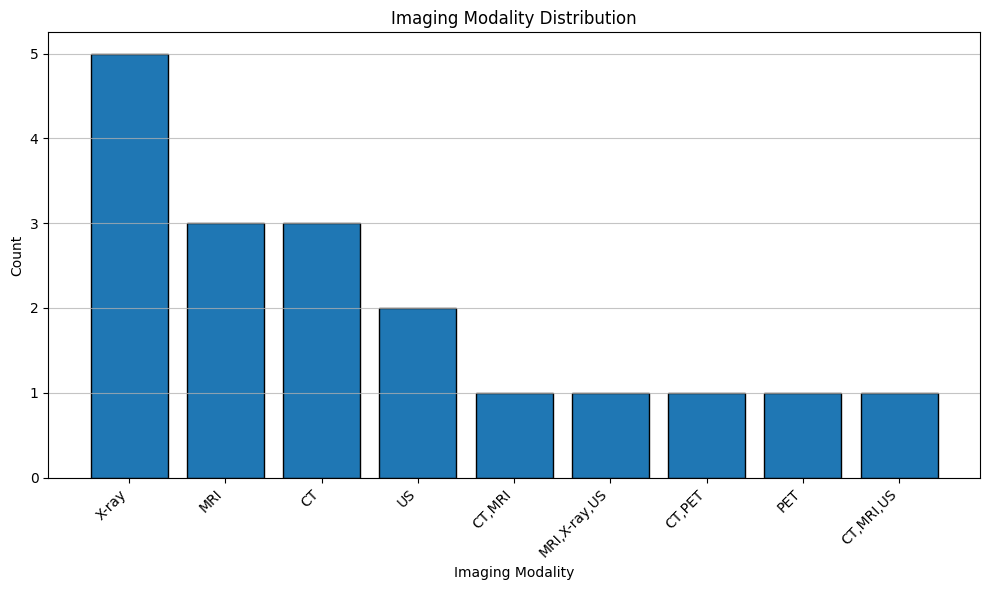

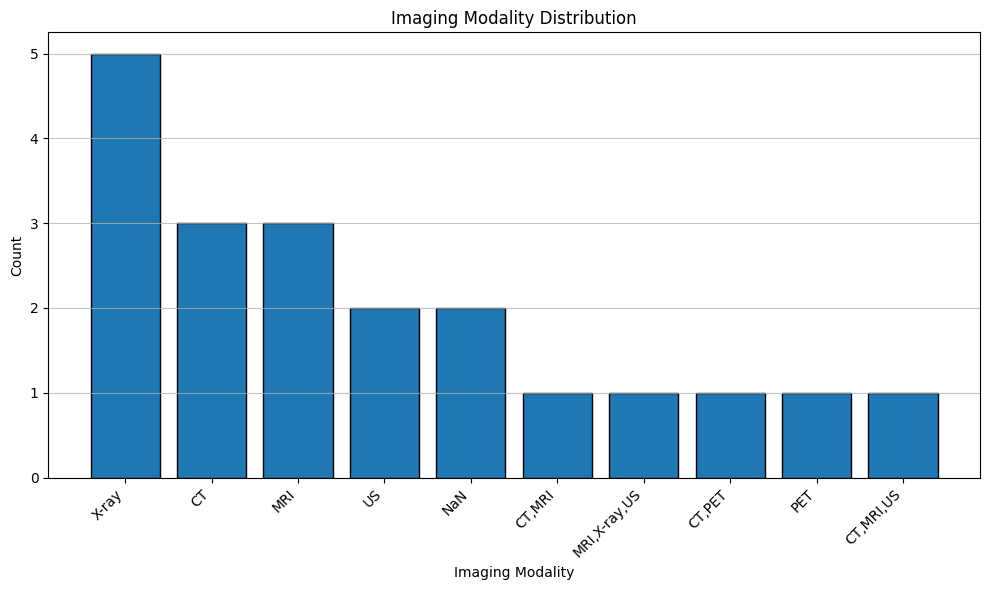

In [9]:
labels, values = count_values_in_comma_joined_column(df, "modalities")
plot_bar_chart(labels, values, xlabel="Imaging Modality", ylabel="Count", title="Imaging Modality Distribution")

counts = df["modalities"].value_counts()
plot_bar_chart(counts.index, counts.values, xlabel="Imaging Modality", ylabel="Count", title="Imaging Modality Distribution")

counts = df["modalities"].fillna("NaN").astype(str).value_counts()
plot_bar_chart(counts.index, counts.values, xlabel="Imaging Modality", ylabel="Count", title="Imaging Modality Distribution")

# Body regions

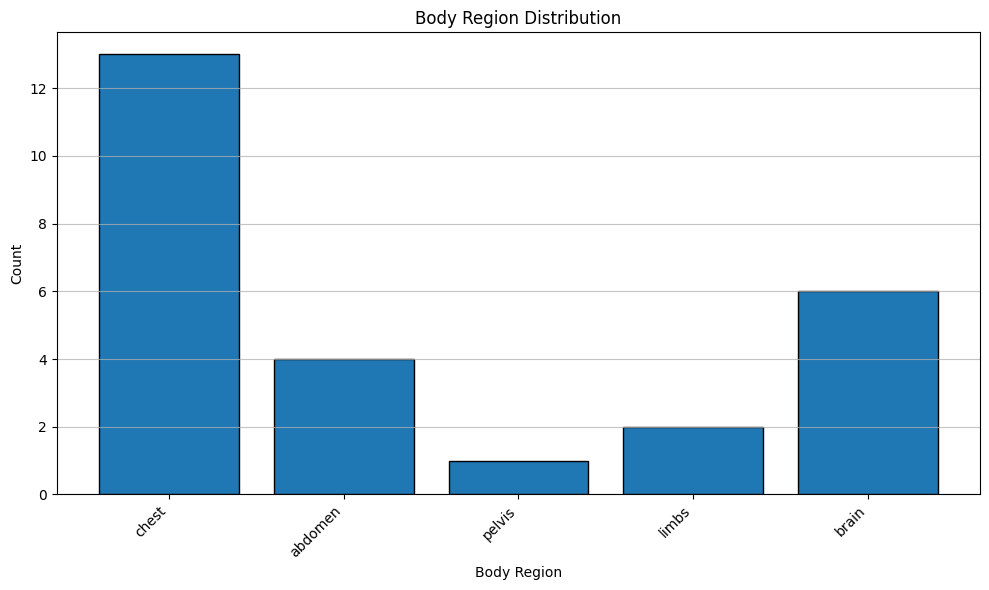

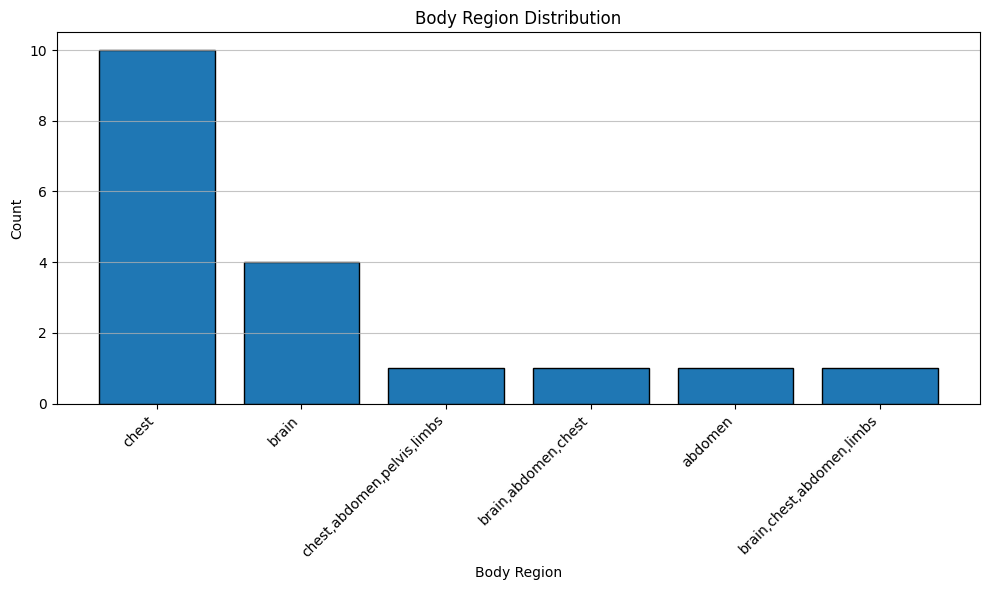

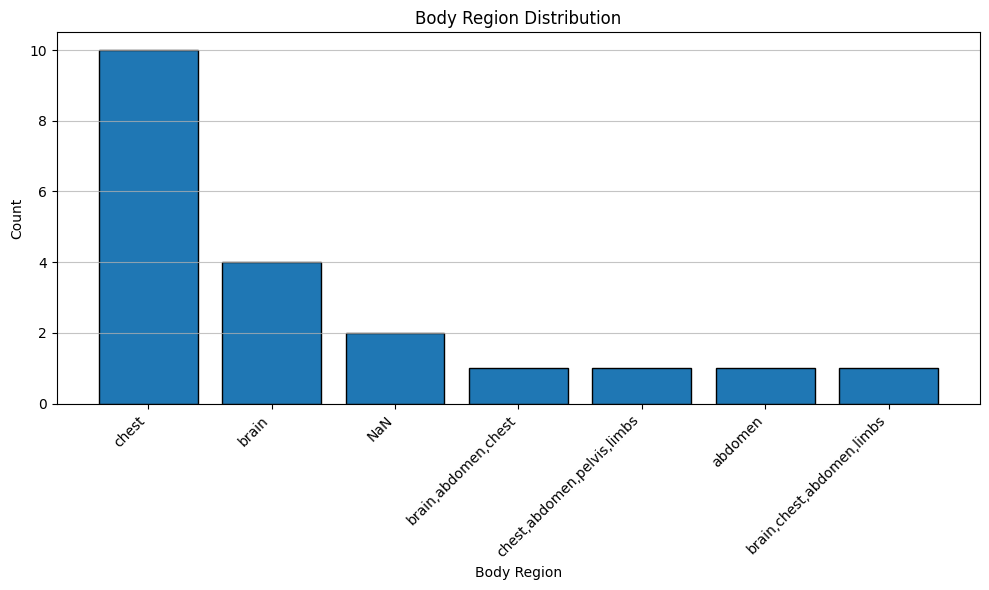

In [10]:
labels, values = count_values_in_comma_joined_column(df, "body_regions")
plot_bar_chart(labels, values, xlabel="Body Region", ylabel="Count", title="Body Region Distribution")

counts = df["body_regions"].value_counts()
plot_bar_chart(counts.index, counts.values, xlabel="Body Region", ylabel="Count", title="Body Region Distribution")

counts = df["body_regions"].fillna("NaN").astype(str).value_counts()
plot_bar_chart(counts.index, counts.values, xlabel="Body Region", ylabel="Count", title="Body Region Distribution")

# Additional data

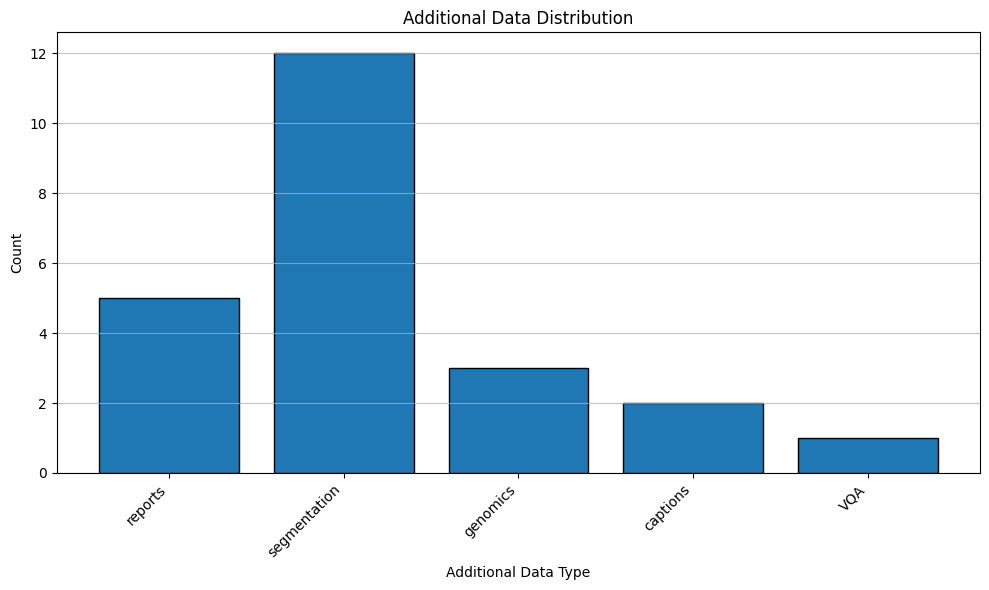

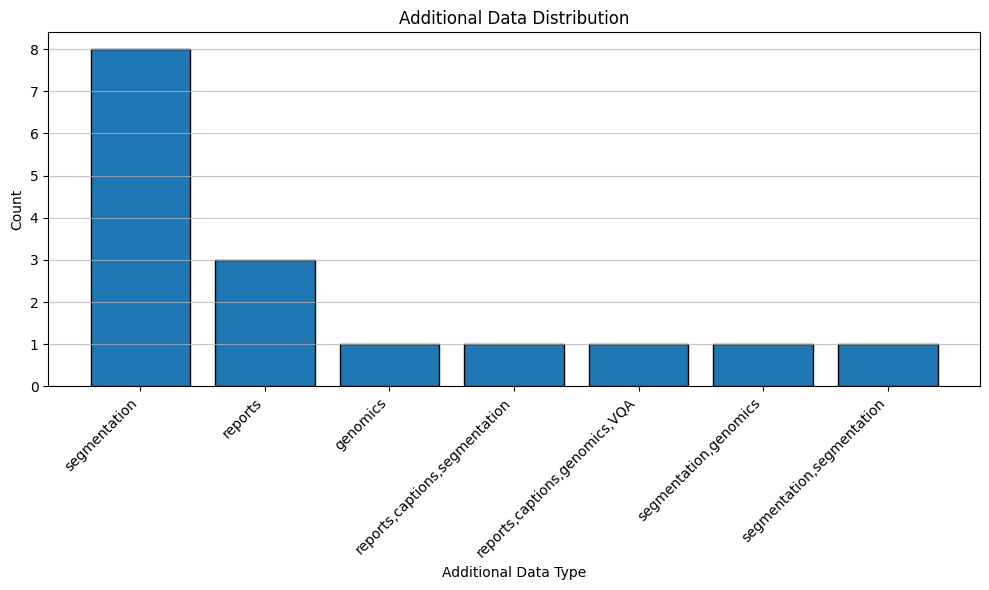

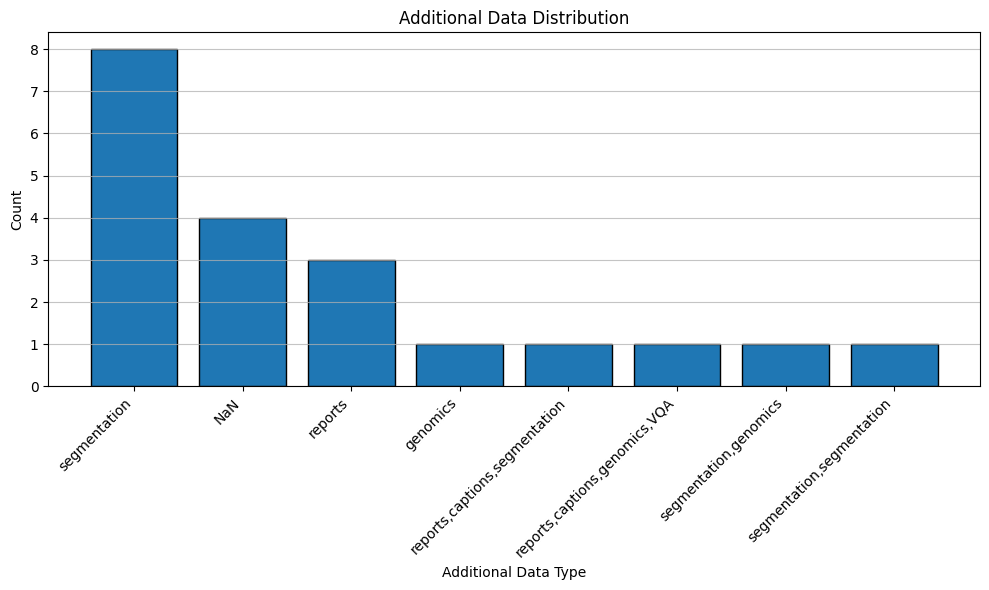

In [11]:
labels, values = count_values_in_comma_joined_column(df, "additional_data")
plot_bar_chart(labels, values, xlabel="Additional Data Type", ylabel="Count", title="Additional Data Distribution")

counts = df["additional_data"].value_counts()
plot_bar_chart(counts.index, counts.values, xlabel="Additional Data Type", ylabel="Count", title="Additional Data Distribution")

counts = df["additional_data"].fillna("NaN").astype(str).value_counts()
plot_bar_chart(counts.index, counts.values, xlabel="Additional Data Type", ylabel="Count", title="Additional Data Distribution")

## MeSH terms and PubMed query matches

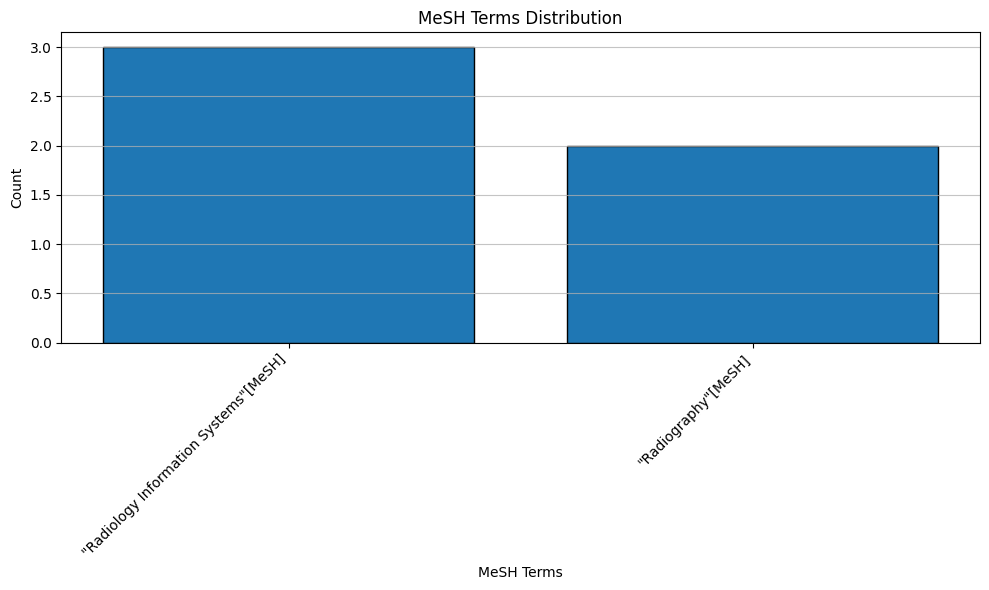

In [12]:
labels, values = count_values_in_comma_joined_column(df, "mesh_terms_in_pubmed_matches")
plot_bar_chart(labels, values, xlabel="MeSH Terms", ylabel="Count", title="MeSH Terms Distribution")

In [13]:
df.head()

,verified,name,num_images,num_patients,modalities,body_regions,additional_data,paper_title,paper_link,paper_year,paper_authors,paper_journal,pmid,paper_citation_count,mesh_terms,pubmed_matches,mesh_terms_in_pubmed_matches,images_per_patient
1,1.0,The Cancer Imaging Archive (TCIA),3300000.0,NaN,"CT,MRI","chest,abdomen,pelvis,limbs",reports,The Cancer Imaging Archive (TCIA): maintaining...,https://doi.org/10.1007/s10278-013-9622-7,2013,"Clark K,Vendt B,Smith K,Freymann J,Kirby J,Kop...",Journal of digital imaging,23884657,2224,"Diagnostic Imaging,Female,Humans,Information S...","[['""information repository""[ti]'], ['""Radiolog...","""Radiology Information Systems""[MeSH]",NaN
3,1.0,LIDC/IDRI Database,7371.0,1018.0,CT,chest,segmentation,The Lung Image Database Consortium (LIDC) and ...,https://doi.org/10.1118/1.3528204,2011,"Armato SG,McLennan G,Bidaut L,McNitt-Gray MF,M...",Medical physics,21452728,938,"Databases, Factual,Diagnosis, Computer-Assiste...","[['database[ti]'], ['""Medical Imaging""[tiab]',...",NaN,7.240668
5,1.0,MIMIC-CXR,377110.0,65379.0,X-ray,chest,reports,"MIMIC-CXR, a de-identified publicly available ...",https://doi.org/10.1038/s41597-019-0322-0,2019,"Johnson AEW,Pollard TJ,Berkowitz SJ,Greenbaum ...",Scientific data,31831740,579,"Algorithms,Data Mining,Databases, Factual,Huma...","[['database[ti]'], ['radiology[tiab]']]",NaN,5.768060
6,1.0,UK Biobank,NaN,100000.0,"MRI,X-ray,US","brain,abdomen,chest",genomics,"The UK Biobank imaging enhancement of 100,000 ...",https://doi.org/10.1038/s41467-020-15948-9,2020,"Littlejohns TJ,Holliday J,Gibson LM,Garratt S,...",Nature communications,32457287,535,"Adult,Aged,Biological Specimen Banks,Female,Hu...","[['""data collection""[ti]'], ['""X-ray""[tiab]', ...",NaN,NaN
7,1.0,MIMIC-II,NaN,25328.0,NaN,NaN,"reports,captions,segmentation",Multiparameter Intelligent Monitoring in Inten...,https://doi.org/10.1097/CCM.0b013e31820a92c6,2011,"Saeed M,Villarroel M,Reisner AT,Clifford G,Leh...",Critical care medicine,21283005,505,"Adult,Artificial Intelligence,Critical Care,Da...","[['database[ti]'], ['radiology[tiab]']]",NaN,NaN


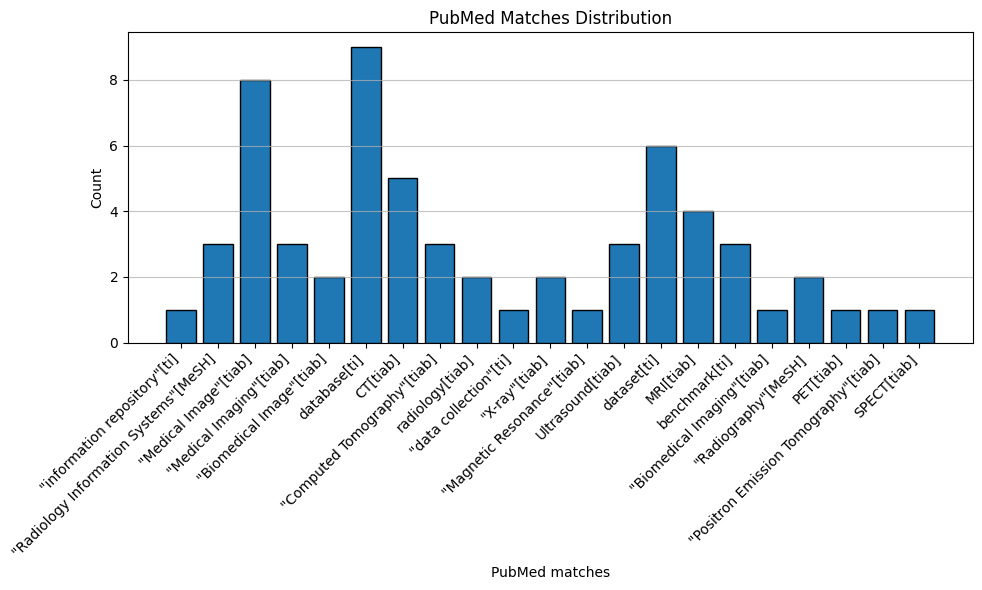

In [14]:
def flatten_and_join(cell):
    if isinstance(cell, str):
        try:
            cell = ast.literal_eval(cell)
        except Exception:
            return ""

    if not isinstance(cell, (list, tuple)):
        return ""

    flat = []
    for sub in cell:
        if isinstance(sub, (list, tuple)):
            flat.extend(sub)
        elif isinstance(sub, str):
            flat.append(sub)

    return ", ".join(flat)


df["pubmed_matches_flattened"] = df["pubmed_matches"].apply(flatten_and_join)

labels, values = count_values_in_comma_joined_column(df, "pubmed_matches_flattened")
plot_bar_chart(labels, values, xlabel="PubMed matches", ylabel="Count", title="PubMed Matches Distribution")

### Compare with unverified data (if available)

/tmp/ipykernel_2862794/2413041947.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unverified["pubmed_matches_flattened"] = df_unverified["pubmed_matches"].apply(flatten_and_join)


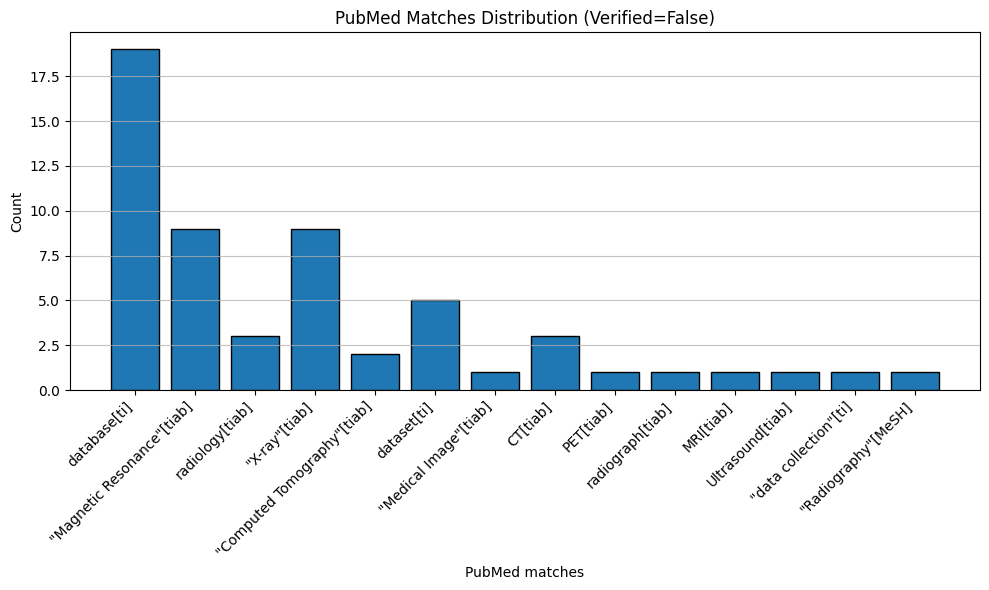

In [15]:
if df_unverified is not None:
    df_unverified["pubmed_matches_flattened"] = df_unverified["pubmed_matches"].apply(flatten_and_join)

    labels, values = count_values_in_comma_joined_column(df_unverified, "pubmed_matches_flattened")
    plot_bar_chart(labels, values, xlabel="PubMed matches", ylabel="Count", title="PubMed Matches Distribution (Verified=False)")

# Citation counts

Column 'paper_year' has 0 / 20 null entries.


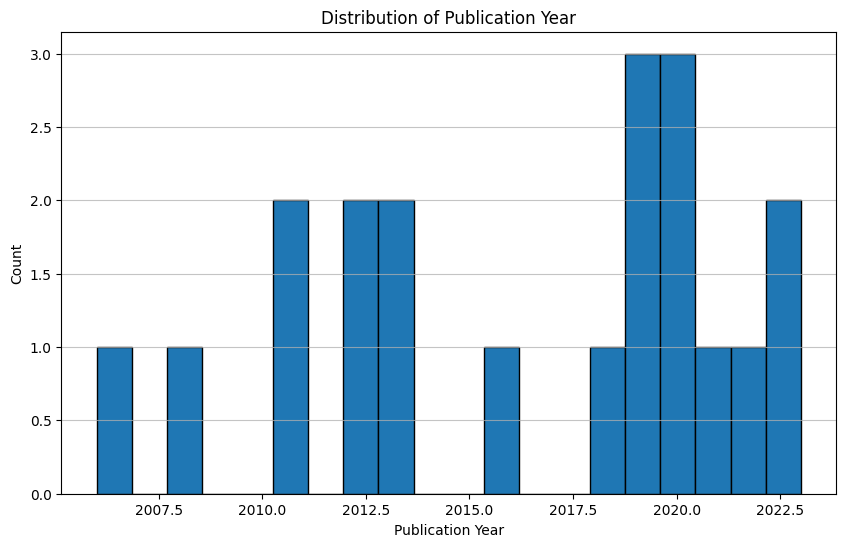

In [16]:
plot_histogram(df, "paper_year", title="Distribution of Publication Year", xlabel="Publication Year", ylabel="Count", xmin=None)

Column 'paper_citation_count' has 0 / 20 null entries.


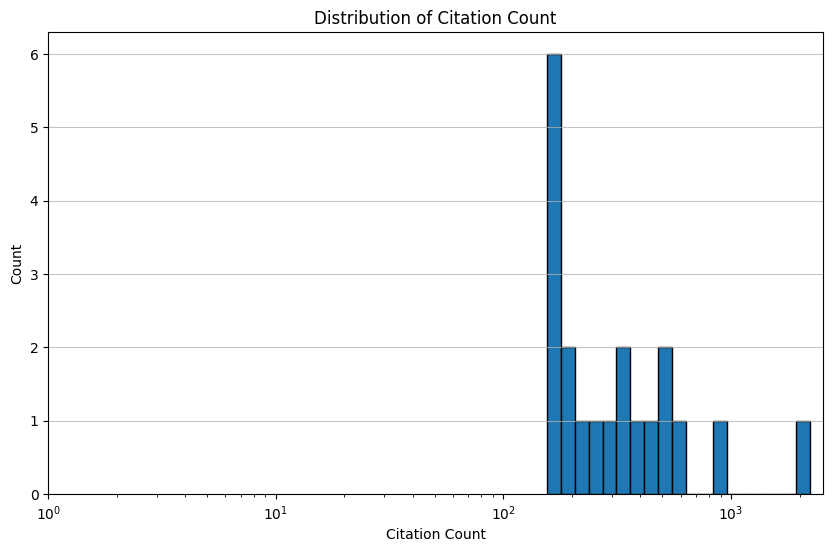

In [17]:
plot_histogram(df, "paper_citation_count", title="Distribution of Citation Count", xlabel="Citation Count", ylabel="Count", xmin=1, logx=True)

# Compare databases

In [ ]:
from radiology_dataset_db.db_validation import compare_dbs, verified_unverified_report, mean_sequence_matcher_in_column, identical_numbers_in_column, mean_jaccard_in_column

df_path_comparison = os.path.join(base_directory, "data", "radiology_db_sample_big.csv")  #!!! change to radiology_db_sample.csv

if not os.path.exists(df_path_comparison):
    raise FileNotFoundError(f"Data file not found at {df_path_comparison}. Please ensure the file exists.")

df_comparison = pd.read_csv(df_path_comparison)
if df_total is not None:
    df = df_total.copy()

if "verified" in df.columns and "verified" not in df_comparison.columns:
    df_comparison = df_comparison.merge(df[["paper_title", "verified"]], on="paper_title", how="left")

In [19]:
compare_dbs(df, df_comparison, merge_col="paper_title")

{'unique_titles_left': 401,
 'unique_titles_right': 401,
 'unique_titles_combined': 401,
 'titles_only_left': 0,
 'titles_only_right': 0,
 'titles_in_both': 401}

In [20]:
if "verified" in df.columns and "verified" in df_comparison.columns:
    verified_unverified_report(df, df_comparison, merge_col="paper_title", verified_col="verified")

KeyError: "None of [Index([-1, -2, -1, -2, -1, -2, -2, -2, -2, -1, -2, -1, -1, -1, -1, -2, -1, -2,\n       -1, -2, -2, -1, -2, -1, -1, -1, -2, -2, -1, -2, -2, -1, -1, -2, -1, -2,\n       -2, -1, -1, -1, -2, -1, -1, -1, -1],\n      dtype='object')] are in the [index]"

In [ ]:
result_df_name = mean_sequence_matcher_in_column(df, df_comparison, column_name="name", merge_col="paper_title")
print(result_df_name.head())

mean_sequence_matcher_in_column for column name
{'mean_ratio': 1.0, 'n_compared': 4}
                                         paper_title  \
0  RadImageNet: An Open Radiologic Deep Learning ...   
1  The UK Biobank imaging enhancement of 100,000 ...   
2  MIMIC-CXR, a de-identified publicly available ...   
3  The Cancer Imaging Archive (TCIA): maintaining...   

                           name_left                         name_right  
0                        RadImageNet                        RadImageNet  
1                         UK Biobank                         UK Biobank  
2                          MIMIC-CXR                          MIMIC-CXR  
3  The Cancer Imaging Archive (TCIA)  The Cancer Imaging Archive (TCIA)  


In [ ]:
result_df_num_images = identical_numbers_in_column(df, df_comparison, column_name="num_images", merge_col="paper_title")
print(result_df_num_images.head())

result_df_num_patients = identical_numbers_in_column(df, df_comparison, column_name="num_patients", merge_col="paper_title")
print(result_df_num_patients.head())

identical_numbers_in_column for column num_images
{'all_identical': True, 'n_compared': 2, 'n_identical': 2, 'identical_fraction': 1.0}
                                         paper_title  num_images_left  \
0  RadImageNet: An Open Radiologic Deep Learning ...        1350000.0   
1  The UK Biobank imaging enhancement of 100,000 ...              NaN   
2  MIMIC-CXR, a de-identified publicly available ...         377110.0   
3  The Cancer Imaging Archive (TCIA): maintaining...        3300000.0   

   num_images_right  
0         1350000.0  
1               NaN  
2               NaN  
3         3300000.0  
identical_numbers_in_column for column num_patients
{'all_identical': True, 'n_compared': 3, 'n_identical': 3, 'identical_fraction': 1.0}
                                         paper_title  num_patients_left  \
0  RadImageNet: An Open Radiologic Deep Learning ...           131872.0   
1  The UK Biobank imaging enhancement of 100,000 ...           100000.0   
2  MIMIC-CXR, a de-identi

In [ ]:
result_df_modalities = mean_jaccard_in_column(df, df_comparison, column_name="modalities", merge_col="paper_title")
print(result_df_modalities.head())

result_df_body_regions = mean_jaccard_in_column(df, df_comparison, column_name="body_regions", merge_col="paper_title")
print(result_df_body_regions.head())

result_df_additional_data = mean_jaccard_in_column(df, df_comparison, column_name="additional_data", merge_col="paper_title")
print(result_df_additional_data.head())

mean_jaccard_in_column for column modalities
{'mean_jaccard': 0.7083333333333333, 'n_compared': 4}
                                         paper_title modalities_left  \
0  RadImageNet: An Open Radiologic Deep Learning ...       CT,MRI,US   
1  The UK Biobank imaging enhancement of 100,000 ...    MRI,X-ray,US   
2  MIMIC-CXR, a de-identified publicly available ...           X-ray   
3  The Cancer Imaging Archive (TCIA): maintaining...          CT,MRI   

   modalities_right  
0         CT,MRI,US  
1               MRI  
2             X-ray  
3  CT,MRI,X-ray,PET  
mean_jaccard_in_column for column body_regions
{'mean_jaccard': 0.7333333333333334, 'n_compared': 4}
                                         paper_title  \
0  RadImageNet: An Open Radiologic Deep Learning ...   
1  The UK Biobank imaging enhancement of 100,000 ...   
2  MIMIC-CXR, a de-identified publicly available ...   
3  The Cancer Imaging Archive (TCIA): maintaining...   

            body_regions_left                bod

In [ ]:
!pip list

Package                                  Version         Build Editable project location
---------------------------------------- --------------- ----- -----------------------------------------------
accelerate                               1.13.0
ag-ui-protocol                           0.1.14
aiofile                                  3.9.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.3
aiosignal                                1.4.0
annotated-doc                            0.0.4
annotated-types                          0.7.0
anthropic                                0.86.0
anyio                                    4.12.1
apache-tvm-ffi                           0.1.9
argcomplete                              3.6.3
astor                                    0.8.1
asttokens                                3.0.1
async-timeout                            5.0.1
attrs                                    26.1.0
Authlib                                  1